# Temperature Forecasting Using LSTM
## Jena Climate Dataset | TensorFlow / Keras

### Project Overview
This project predicts the **next temperature value** from previous temperature observations using a basic Long Short-Term Memory (LSTM) neural network.

### Problem Statement
Weather data is recorded over time, so the values form a **time series**. The temperature at one time is related to temperatures observed earlier. An LSTM can learn these sequential patterns and use them to predict a future temperature.

### Objectives
- Understand the Jena Climate dataset.
- Perform basic data inspection and exploratory analysis.
- Clean and preprocess the temperature data.
- Scale the data for neural-network training.
- Convert the time series into input/output sequences.
- Build a simple TensorFlow/Keras LSTM model.
- Train and evaluate the model.
- Save and load the trained model.
- Use the model in a simple Streamlit application.

### Why LSTM?
A normal machine-learning model does not naturally understand the order of time-series observations. LSTM is a type of Recurrent Neural Network (RNN) designed to learn patterns from sequential data.

## 1. Import Required Libraries

### Why?
We need different libraries for different tasks:

- **Pandas** → load and manipulate the dataset.
- **NumPy** → numerical operations and sequence creation.
- **Matplotlib / Seaborn** → visualization.
- **Scikit-learn** → scaling and regression metrics.
- **TensorFlow/Keras** → build and train the LSTM model.
- **Joblib** → save the scaler for later use in Streamlit.

These are basic and commonly used Python libraries for an ML/DL project.

In [47]:
import sys
print(sys.version)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [48]:
print(sys.executable)

c:\Users\satya\AppData\Local\Programs\Python\Python311\python.exe


In [49]:
%pip install tensorflow kagglehub

Note: you may need to restart the kernel to use updated packages.


In [50]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mnassrib/jena-climate")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\satya\.cache\kagglehub\datasets\mnassrib\jena-climate\versions\1


In [51]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Load the Dataset

### Dataset Source
The **Jena Climate Dataset** contains weather measurements collected at the Max Planck Institute for Biogeochemistry in Jena, Germany.

It contains measurements such as:
- Temperature
- Pressure
- Humidity
- Wind-related measurements
- Other atmospheric variables

### Why use this dataset?
It is a well-known time-series dataset and is suitable for demonstrating forecasting using LSTM.

### What are we predicting?
We use **`T (degC)`** as our target variable.

The objective is:

**Previous temperatures → Next temperature**

In [53]:
# Place the downloaded Jena Climate CSV in the same folder as this notebook.
import os
DATA_PATH = r"C:\Users\satya\OneDrive\Desktop\jena_climate_2009_2016.csv"

# Set a manageable number of rows for a quick student project.
# Change to None if you want to use the complete dataset.
MAX_ROWS = 20000

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        "Dataset not found. Download the Jena Climate CSV and "
        "place it in the notebook folder, then update DATA_PATH if required."
    )

df = pd.read_csv(DATA_PATH)

if MAX_ROWS is not None:
    df = df.iloc[:MAX_ROWS].copy()

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (20000, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 3. Understand the Dataset

### Why?
Before building a model, we need to understand the data.

We check:
- Number of rows and columns
- Column names
- Data types
- Statistical information
- Missing values

This is an important basic ML step because the model should not be trained before understanding the input data.

In [54]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nBasic statistical summary:")
display(df.describe().T)

Number of rows: 20000
Number of columns: 15

Column names:
['Date Time', 'p (mbar)', 'T (degC)', 'Tpot (K)', 'Tdew (degC)', 'rh (%)', 'VPmax (mbar)', 'VPact (mbar)', 'VPdef (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'rho (g/m**3)', 'wv (m/s)', 'max. wv (m/s)', 'wd (deg)']

Data types:
Date Time           object
p (mbar)           float64
T (degC)           float64
Tpot (K)           float64
Tdew (degC)        float64
rh (%)             float64
VPmax (mbar)       float64
VPact (mbar)       float64
VPdef (mbar)       float64
sh (g/kg)          float64
H2OC (mmol/mol)    float64
rho (g/m**3)       float64
wv (m/s)           float64
max. wv (m/s)      float64
wd (deg)           float64
dtype: object

Basic statistical summary:


,count,mean,std,min,25%,50%,75%,max
p (mbar),20000.0,987.683354,10.437247,944.58,981.8475,989.320,995.37,1005.71
T (degC),20000.0,4.390170,7.644761,-23.01,-0.8500,3.890,9.27,25.92
Tpot (K),20000.0,278.544739,7.828243,250.60,273.2900,278.500,283.39,300.36
Tdew (degC),20000.0,0.523080,5.968687,-25.01,-2.9800,0.710,4.94,12.59
rh (%),20000.0,78.242118,15.886260,29.93,68.2375,82.500,90.90,100.00
VPmax (mbar),20000.0,9.459937,5.154149,0.95,5.7400,8.075,11.70,33.51
VPact (mbar),20000.0,6.846165,2.681810,0.79,4.9000,6.430,8.69,14.60
VPdef (mbar),20000.0,2.613732,3.337843,0.00,0.5400,1.310,3.08,21.69
sh (g/kg),20000.0,4.327418,1.700399,0.50,3.1000,4.070,5.50,9.24
H2OC (mmol/mol),20000.0,6.936235,2.718471,0.80,4.9800,6.530,8.81,14.77


## 4. Features and Target Variable

### Features
A feature is an input variable used by the model.

For this project, we use historical values of:

**`T (degC)`**

### Target
The target is the value we want to predict.

Here, the target is also:

**`T (degC)`**

This is called **univariate time-series forecasting** because we use one main variable (temperature) to predict its future value.

### Why start with one feature?
A univariate LSTM is easier to understand and explain. Once this works, additional weather variables can be added as a future improvement.

In [55]:
TARGET = "T (degC)"

if TARGET not in df.columns:
    raise ValueError(f"{TARGET} was not found in the dataset.")

print("Feature used:", TARGET)
print("Target variable:", TARGET)
print("Target data type:", df[TARGET].dtype)
print("Minimum temperature:", df[TARGET].min())
print("Maximum temperature:", df[TARGET].max())

Feature used: T (degC)
Target variable: T (degC)
Target data type: float64
Minimum temperature: -23.01
Maximum temperature: 25.92


## 5. Convert Date/Time Information

### Why?
The dataset contains a timestamp column. Time-series data should be kept in chronological order.

We convert the date column into a proper datetime format and sort the rows.

### Important ML concept
Unlike normal classification/regression datasets, we **must preserve the time order**. We should not randomly shuffle the observations before splitting them.

In [56]:
if "Date Time" in df.columns:
    df["Date Time"] = pd.to_datetime(df["Date Time"], errors="coerce")
    df = df.sort_values("Date Time").reset_index(drop=True)

print("Data is now in chronological order.")
df.head()

Data is now in chronological order.


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


## 6. Check Missing Values

### Why?
Missing values can cause problems during scaling, sequence creation, and model training.

We first check how many missing values exist in every column.

If the target temperature contains missing values, we will handle them before training.

In [57]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Date Time          11361
p (mbar)               0
T (degC)               0
Tpot (K)               0
Tdew (degC)            0
rh (%)                 0
VPmax (mbar)           0
VPact (mbar)           0
VPdef (mbar)           0
sh (g/kg)              0
H2OC (mmol/mol)        0
rho (g/m**3)           0
wv (m/s)               0
max. wv (m/s)          0
wd (deg)               0
dtype: int64


## 7. Check Duplicate and Invalid Values

### Why?
Duplicate observations can unnecessarily repeat information.

Infinite values are also invalid for numerical calculations.

We will:
1. Replace infinite values with missing values.
2. Remove duplicate rows.
3. Handle missing temperature values.

In [58]:
# Replace positive/negative infinity with NaN
df = df.replace([np.inf, -np.inf], np.nan)

# Count duplicates before removing them
print("Duplicate rows before removal:", df.duplicated().sum())

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

print("Duplicate rows after removal:", df.duplicated().sum())

Duplicate rows before removal: 2
Duplicate rows after removal: 0


## 8. Handle Missing Temperature Values

### Why?
The LSTM requires numerical values for every position in a sequence.

For missing temperature observations, we use **linear interpolation**. This estimates a missing value from nearby observations.

Then:
- `ffill()` fills any remaining gaps using the previous value.
- `bfill()` fills any remaining gaps using the next value.

This is a simple preprocessing approach suitable for this project.

In [59]:
print("Missing temperature values before:", df[TARGET].isna().sum())

df[TARGET] = df[TARGET].interpolate(method="linear")
df[TARGET] = df[TARGET].ffill().bfill()

print("Missing temperature values after:", df[TARGET].isna().sum())

Missing temperature values before: 0
Missing temperature values after: 0


## 9. Exploratory Data Analysis — Temperature Over Time

### Why?
A time-series plot helps us see how temperature changes over time.

We are looking for:
- Trends
- Repeating patterns
- Large fluctuations
- Unusual values

This also helps justify why a sequential model such as LSTM is appropriate.

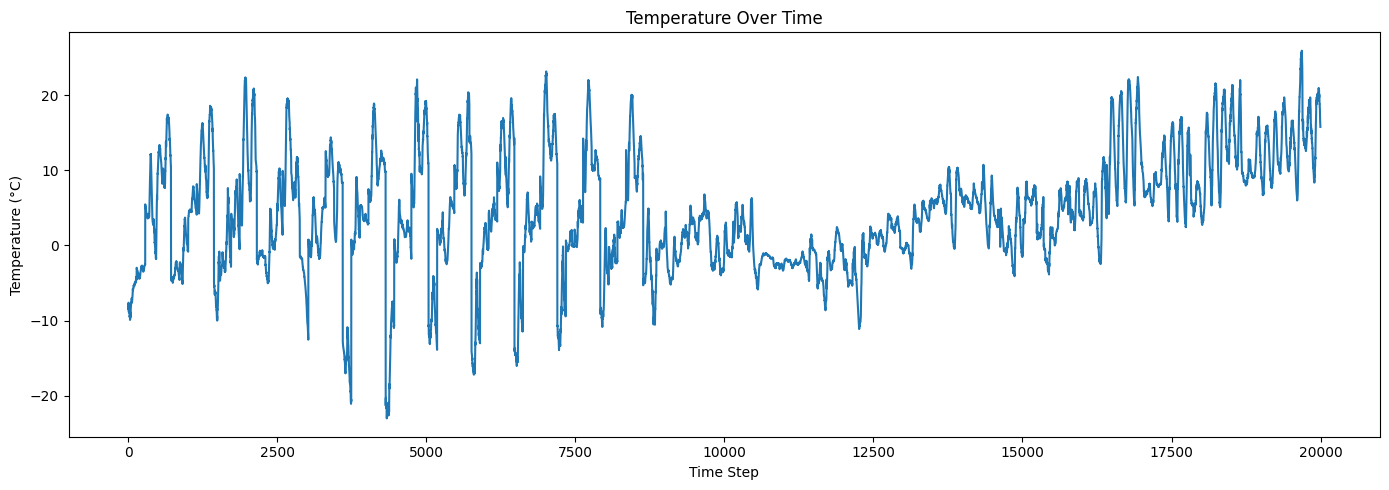

In [60]:
plt.figure(figsize=(14, 5))
plt.plot(df[TARGET].values)
plt.title("Temperature Over Time")
plt.xlabel("Time Step")
plt.ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

## 10. Temperature Distribution

### Why?
A histogram shows how the temperature values are distributed.

It helps us understand:
- Typical temperature range
- Whether the values are concentrated around certain temperatures
- Whether extreme values exist

This is basic exploratory data analysis before model development.

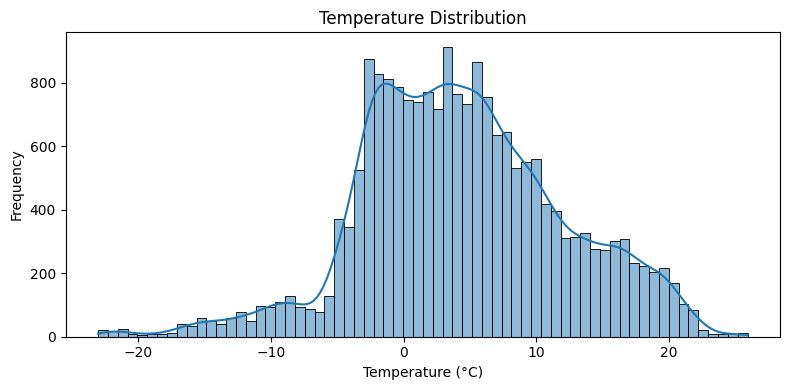

In [61]:
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], kde=True)
plt.title("Temperature Distribution")
plt.xlabel("Temperature (°C)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 11. Prepare the Temperature Data

We only need the target temperature for our basic univariate LSTM.

### Why reshape?
Scikit-learn's scaler expects a 2-dimensional array:

`(rows, features)`

Therefore, we reshape the temperature column to:

`(number_of_rows, 1)`

In [62]:
temperature = df[TARGET].astype("float32").values.reshape(-1, 1)

print("Temperature shape:", temperature.shape)

Temperature shape: (19998, 1)


## 12. Train / Validation / Test Split

### Why?
We divide the data into three chronological parts:

- **Training set (70%)** → used to learn model parameters.
- **Validation set (15%)** → used during training to monitor generalization.
- **Test set (15%)** → used only for final evaluation.

### Important
We do **not** randomly shuffle the data.

For forecasting, the model should learn from the past and be tested on later observations. Random splitting could allow future information to enter the training set.

In [63]:
n = len(temperature)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_data = temperature[:train_end]
val_data = temperature[train_end:val_end]
test_data = temperature[val_end:]

print("Training samples:", len(train_data))
print("Validation samples:", len(val_data))
print("Testing samples:", len(test_data))

Training samples: 13998
Validation samples: 3000
Testing samples: 3000


## 13. Feature Scaling / Normalization

### Why normalize?
Temperature values may be around different numerical ranges. Neural networks generally train more efficiently when inputs are scaled to a smaller range.

We use **MinMaxScaler** to transform the temperature values approximately into the range 0 to 1.

### Important data-leakage rule
The scaler is fitted **only on training data**.

We then use the same scaler to transform validation and test data.

This prevents information from the test set from influencing preprocessing.

In [64]:
scaler = MinMaxScaler(feature_range=(0, 1))

train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)
test_scaled = scaler.transform(test_data)

print("Original training range:",
      train_data.min(), "to", train_data.max())

print("Scaled training range:",
      train_scaled.min(), "to", train_scaled.max())

Original training range: -23.01 to 23.16
Scaled training range: 0.0 to 1.0


## 14. Create Time-Series Sequences

### Why?
An LSTM expects sequences rather than individual independent rows.

We choose:

**Sequence length = 24**

This means the model receives 24 previous temperature observations and predicts the next one.

Example:

```text
Input:
T1, T2, T3, ... T24

Target:
T25
```

Then the next sequence becomes:

```text
Input:
T2, T3, T4, ... T25

Target:
T26
```

This creates many training examples from one continuous time series.

In [65]:
SEQUENCE_LENGTH = 24

def create_sequences(data, sequence_length):
    X = []
    y = []

    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i])
        y.append(data[i])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X_train, y_train = create_sequences(train_scaled, SEQUENCE_LENGTH)
X_val, y_val = create_sequences(val_scaled, SEQUENCE_LENGTH)
X_test, y_test = create_sequences(test_scaled, SEQUENCE_LENGTH)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (13974, 24, 1)
y_train: (13974, 1)
X_val: (2976, 24, 1)
y_val: (2976, 1)
X_test: (2976, 24, 1)
y_test: (2976, 1)


## 15. Understand the LSTM Input Shape

The LSTM input has three dimensions:

```text
(samples, time steps, features)
```

For example:

```text
X_train = (number of sequences, 24, 1)
```

### Meaning
- **Samples** → number of training sequences.
- **24** → previous time steps used as input.
- **1** → one feature: temperature.

This is one of the most important concepts to explain during the project viva.

In [66]:
print("Number of training sequences:", X_train.shape[0])
print("Time steps per sequence:", X_train.shape[1])
print("Number of features:", X_train.shape[2])

Number of training sequences: 13974
Time steps per sequence: 24
Number of features: 1


# 16. Build the Basic LSTM Model

### Model Architecture

```text
Input
  ↓
LSTM(50)
  ↓
Dropout(0.20)
  ↓
Dense(1)
  ↓
Temperature Prediction
```

### Why LSTM?
LSTM is a type of Recurrent Neural Network designed for sequential data. It can learn relationships between previous observations and later observations.

### Why 50 LSTM units?
50 units provide enough capacity for a small student project while keeping the model simple.

### Why Dropout?
Dropout randomly ignores a small percentage of neurons during training. This helps reduce overfitting.

### Why Dense(1)?
We predict one continuous number — temperature — so the output layer contains one neuron.

### Activation function
The final Dense layer uses the default **linear activation**, which is appropriate for regression because temperature is a continuous value.

In [67]:
model = keras.Sequential([
    layers.Input(shape=(SEQUENCE_LENGTH, 1)),
    layers.LSTM(50),
    layers.Dropout(0.20),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

## 17. Loss Function and Optimizer

### Mean Squared Error (MSE)
MSE calculates the average squared difference between actual and predicted temperature.

Why use it?
- Temperature forecasting is a **regression** problem.
- MSE is commonly used for regression.
- Larger errors receive more penalty.

### Adam Optimizer
Adam updates the model's weights during training to reduce the loss.

It is a good basic optimizer because it generally works well without requiring complicated manual tuning.

## 18. Train the LSTM Model

### Batch Size
We use a batch size of **64**. The model processes 64 sequences at a time before updating its weights.

### Epochs
We allow a maximum of **20 epochs**.

### Early Stopping
Training stops if validation loss does not improve for several epochs.

### Why?
Training for too many epochs can cause overfitting. Early stopping helps keep the model at a useful point.

In [68]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0095 - mae: 0.0640 - val_loss: 4.7841e-04 - val_mae: 0.0152
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0030 - mae: 0.0397 - val_loss: 3.6838e-04 - val_mae: 0.0142
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0026 - mae: 0.0360 - val_loss: 1.9582e-04 - val_mae: 0.0095
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0022 - mae: 0.0331 - val_loss: 2.7584e-04 - val_mae: 0.0124
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0021 - mae: 0.0321 - val_loss: 2.4960e-04 - val_mae: 0.0118
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0019 - mae: 0.0306 - val_loss: 3.7331e-04 - val_mae: 0.0163
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0018 - mae: 0.0291 - val_loss: 1.4476e-04 - val_mae: 0.0084
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0016 - mae: 0.0276 - val_loss: 2.0246e-04 - val_mae: 0.0113
Epoch 9/20
219/219

## 19. Training and Validation Loss

### Why?
We compare training loss and validation loss across epochs.

- If both decrease, the model is learning.
- If training loss keeps decreasing but validation loss starts increasing, overfitting may be occurring.
- A small gap between them generally indicates better generalization.

The loss here is **MSE**.

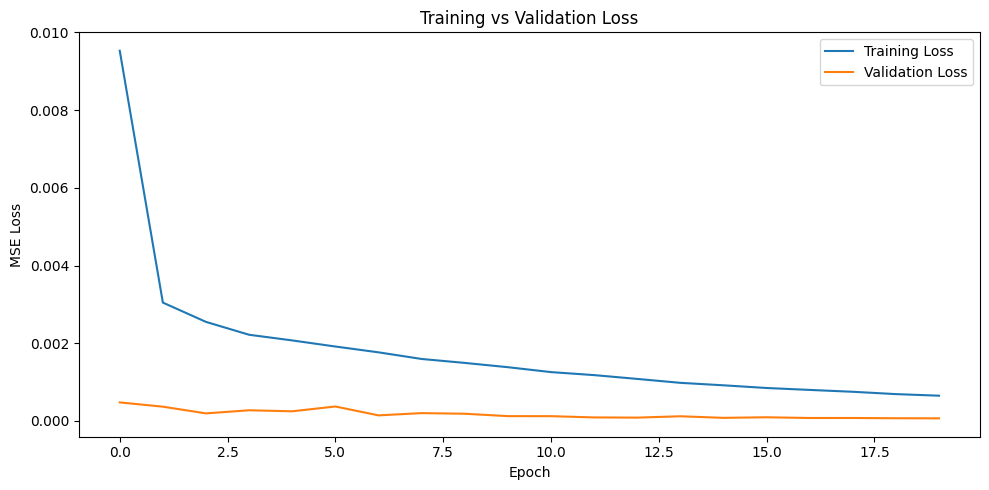

In [69]:
plt.figure(figsize=(10, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Make Predictions on the Test Set

The test set was not used to train the model.

Now the trained LSTM predicts temperatures for the unseen test sequences.

The predictions are still scaled between approximately 0 and 1, so we will convert them back to Celsius in the next step.

In [70]:
y_pred_scaled = model.predict(X_test, verbose=0)

print("Prediction shape:", y_pred_scaled.shape)

Prediction shape: (2976, 1)


## 21. Convert Predictions Back to Celsius

### Why?
The model was trained using normalized values.

For meaningful evaluation and interpretation, we need the predictions in their original unit: **°C**.

`inverse_transform()` converts the scaled values back to the original temperature scale.

In [71]:
y_test_actual = scaler.inverse_transform(y_test)
y_pred_actual = scaler.inverse_transform(y_pred_scaled)

print("First 5 actual temperatures:")
print(y_test_actual[:5].flatten())

print("\nFirst 5 predicted temperatures:")
print(y_pred_actual[:5].flatten())

First 5 actual temperatures:
[9.570001 9.300001 9.169999 9.109999 9.03    ]

First 5 predicted temperatures:
[9.552749 9.492803 9.31055  9.116981 8.978139]


# 22. Model Evaluation

Because temperature is a continuous value, this is a **regression** problem.

Therefore, classification metrics such as:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion matrix

are not appropriate as the primary evaluation metrics.

We use:

### MAE — Mean Absolute Error
Average absolute prediction error.

### MSE — Mean Squared Error
Average squared prediction error.

### RMSE — Root Mean Squared Error
Square root of MSE. It is expressed in °C.

### R² Score
Shows how much variation in the target is explained by the model.

For MAE, MSE and RMSE, **lower values are better**. For R², values closer to 1 generally indicate a stronger fit.

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
mae = mean_absolute_error(y_test_actual, y_pred_actual)
mse = mean_squared_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_actual, y_pred_actual)

print(f"MAE  : {mae:.4f} °C")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f} °C")
print(f"R²   : {r2:.4f}")

MAE  : 0.2432 °C
MSE  : 0.1162
RMSE : 0.3408 °C
R²   : 0.9948


## 23. Evaluation Results Table

A table makes the final model performance easy to present in a project review.

In [73]:
results = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R² Score"],
    "Value": [mae, mse, rmse, r2]
})

display(results)

,Metric,Value
0,MAE,0.243229
1,MSE,0.116170
2,RMSE,0.340838
3,R² Score,0.994805


## 24. Actual vs Predicted Temperature

### Why?
A graph makes it easier to understand whether the model follows the real temperature pattern.

If predicted values follow the actual values closely, the model is capturing useful temporal patterns.

We display a limited number of test observations so the graph remains readable.

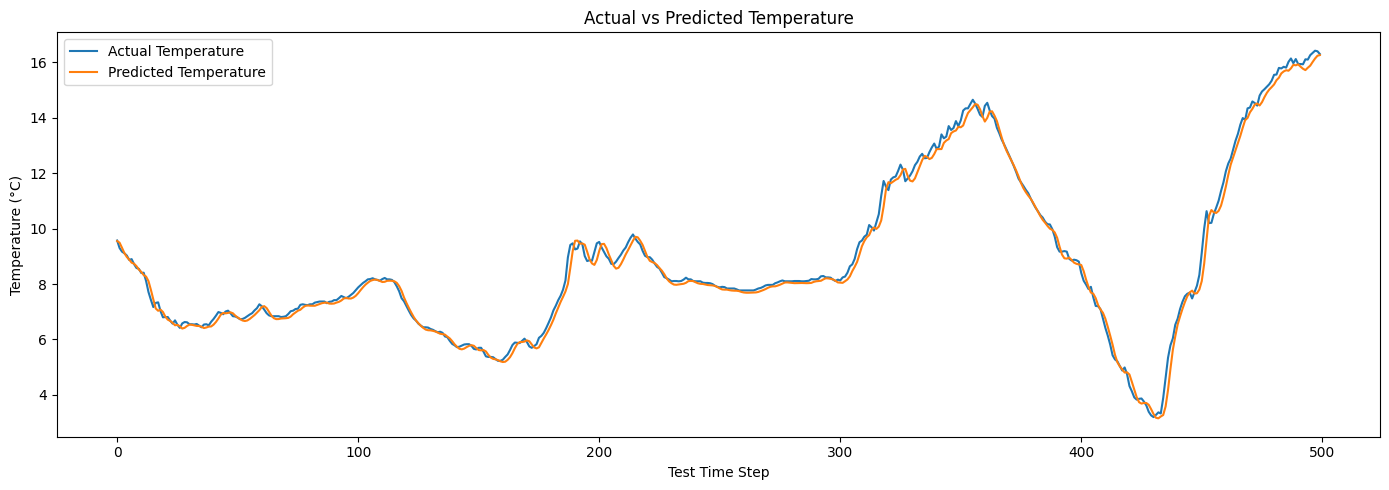

In [74]:
plot_n = min(500, len(y_test_actual))

plt.figure(figsize=(14, 5))

plt.plot(
    y_test_actual[:plot_n],
    label="Actual Temperature"
)

plt.plot(
    y_pred_actual[:plot_n],
    label="Predicted Temperature"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Test Time Step")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.tight_layout()
plt.show()

## 25. Actual vs Predicted Scatter Plot

### Why?
The ideal prediction would be equal to the actual value.

The dashed diagonal line represents:

**Predicted = Actual**

Points closer to this line indicate smaller prediction errors.

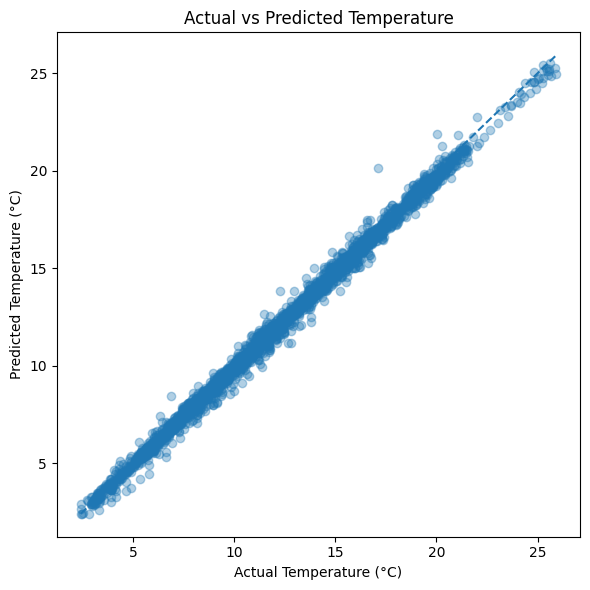

In [75]:
plt.figure(figsize=(6, 6))

plt.scatter(
    y_test_actual,
    y_pred_actual,
    alpha=0.35
)

minimum = min(y_test_actual.min(), y_pred_actual.min())
maximum = max(y_test_actual.max(), y_pred_actual.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.title("Actual vs Predicted Temperature")
plt.xlabel("Actual Temperature (°C)")
plt.ylabel("Predicted Temperature (°C)")
plt.tight_layout()
plt.show()

# 26. Save the Trained Model

### Why save the model?
Training can take time. We do not want to train the model every time the Streamlit application starts.

We save:
- The trained neural network as `.keras`
- The fitted scaler as `.pkl`

The scaler is also important because new user input must be transformed in exactly the same way as the training data.

In [76]:
MODEL_PATH = "temperature_lstm.keras"
SCALER_PATH = "temperature_scaler.pkl"

model.save(MODEL_PATH)
joblib.dump(scaler, SCALER_PATH)

print("Model saved as:", MODEL_PATH)
print("Scaler saved as:", SCALER_PATH)

Model saved as: temperature_lstm.keras
Scaler saved as: temperature_scaler.pkl


# 27. Load the Saved Model

### Why?
We should demonstrate that the saved model can be loaded independently.

This is also the same process that will be used by the Streamlit application.

In [77]:
loaded_model = keras.models.load_model(MODEL_PATH)
loaded_scaler = joblib.load(SCALER_PATH)

print("Model loaded successfully.")
print("Scaler loaded successfully.")

Model loaded successfully.
Scaler loaded successfully.


## 28. Make a New Prediction Using the Loaded Model

### What are we doing?
We take one unseen sequence containing the most recent 24 test temperatures.

Steps:
1. Take 24 temperature values.
2. Scale them using the saved scaler.
3. Reshape them into LSTM input format.
4. Pass them to the loaded model.
5. Convert the prediction back to °C.

In [78]:
# Take the last 24 test observations
recent_temperatures = test_data[-SEQUENCE_LENGTH:]

# Scale using the saved scaler
recent_scaled = loaded_scaler.transform(recent_temperatures)

# LSTM expects: samples, time steps, features
new_input = recent_scaled.reshape(1, SEQUENCE_LENGTH, 1)

# Predict
new_prediction_scaled = loaded_model.predict(new_input, verbose=0)

# Convert back to Celsius
new_prediction = loaded_scaler.inverse_transform(
    new_prediction_scaled
)[0, 0]

print(f"Predicted next temperature: {new_prediction:.2f} °C")

Predicted next temperature: 15.45 °C


# 29. Streamlit Deployment

We now create a simple Streamlit application.

### Application workflow

```text
User enters 24 recent temperatures
            ↓
Validate input
            ↓
Load saved scaler
            ↓
Normalize input
            ↓
Reshape into LSTM sequence
            ↓
Load saved LSTM model
            ↓
Predict next temperature
            ↓
Convert prediction to °C
            ↓
Display result
```

### User Interface
The application provides:
- Input box for recent temperatures
- Prediction button
- Predicted temperature
- Simple temperature chart
- Basic error handling

Save the generated code below as `app.py`.

In [79]:
app_code = r'''
import streamlit as st
import numpy as np
import pandas as pd
import joblib
from tensorflow import keras

MODEL_PATH = "temperature_lstm.keras"
SCALER_PATH = "temperature_scaler.pkl"
SEQUENCE_LENGTH = 24

st.set_page_config(
    page_title="Temperature Forecasting",
    page_icon="🌡️"
)

st.title("🌡️ Temperature Forecasting Using LSTM")
st.write(
    "Enter the most recent 24 temperature values to predict "
    "the next temperature."
)

@st.cache_resource
def load_model_and_scaler():
    model = keras.models.load_model(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    return model, scaler

model, scaler = load_model_and_scaler()

input_text = st.text_area(
    "Enter 24 temperatures in °C, separated by commas:",
    value=", ".join(["15.0"] * SEQUENCE_LENGTH)
)

if st.button("Predict Temperature"):

    try:
        temperatures = np.array(
            [float(x.strip()) for x in input_text.split(",")],
            dtype=np.float32
        )

        if len(temperatures) != SEQUENCE_LENGTH:
            st.error(
                f"Please enter exactly {SEQUENCE_LENGTH} temperature values."
            )

        else:
            # Scale the input in the same way as training data
            scaled_input = scaler.transform(
                temperatures.reshape(-1, 1)
            )

            # Create LSTM input shape
            X_new = scaled_input.reshape(
                1, SEQUENCE_LENGTH, 1
            )

            # Predict
            prediction_scaled = model.predict(
                X_new,
                verbose=0
            )

            # Convert back to Celsius
            prediction = scaler.inverse_transform(
                prediction_scaled
            )[0, 0]

            st.success(
                f"Predicted Next Temperature: {prediction:.2f} °C"
            )

            chart_data = pd.DataFrame({
                "Temperature (°C)": temperatures
            })

            st.line_chart(chart_data)

    except ValueError:
        st.error(
            "Please enter only valid numeric temperature values."
        )
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [80]:
%pip install streamlit

Note: you may need to restart the kernel to use updated packages.


In [83]:
import streamlit as st

st.title("My Streamlit App")
st.write("Hello World!")

2026-09-19 09:54:51.209 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 09:54:51.495 
  command:

    streamlit run C:\Users\satya\AppData\Roaming\Python\Python311\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-09-19 09:54:51.495 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 09:54:51.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 09:54:51.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 09:54:51.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-09-19 09:54:51.498 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


## 30. Run the Streamlit Application

Make sure these files are in the same project folder:

```text
temperature_lstm.keras
temperature_scaler.pkl
app.py
```

Install the required packages:

```bash
pip install streamlit tensorflow pandas numpy scikit-learn matplotlib seaborn joblib
```

Then run:

```bash
streamlit run app.py
```

### Expected Application

The user enters 24 recent temperature values and clicks **Predict Temperature**.

The application then:
- Loads the saved model.
- Loads the scaler.
- Preprocesses the input.
- Predicts the next temperature.
- Displays the result.

# 31. Project Conclusion

In this project, we developed a basic **LSTM-based temperature forecasting model** using the Jena Climate Dataset.

### What we learned
- Temperature data is a time series.
- Time order must be preserved during splitting.
- Scaling is useful for neural-network training.
- LSTM accepts data in `(samples, time steps, features)` format.
- Dropout can help reduce overfitting.
- MSE is suitable as a regression loss.
- MAE, MSE, RMSE and R² can be used to evaluate temperature predictions.
- A trained model and scaler can be saved and reused.
- Streamlit can provide a simple interface for model deployment.

### Final result
The model uses the previous 24 temperature observations to predict the next temperature observation.

# 32. Future Scope

The current project uses a simple **univariate LSTM**. It can be improved in several ways:

1. **Multivariate LSTM**  
   Use temperature together with humidity, pressure, wind speed and other weather measurements.

2. **Multi-step forecasting**  
   Predict the next 6, 12 or 24 temperature values instead of only one.

3. **Model comparison**  
   Compare LSTM with GRU, a simple RNN, or traditional forecasting methods.

4. **Hyperparameter tuning**  
   Experiment with sequence length, LSTM units, batch size and learning rate.

5. **Real-time deployment**  
   Connect the Streamlit application to a weather API for live forecasting.

# 33. Simple Viva Questions and Answers

### Q1. Why did you use LSTM?
LSTM is designed for sequential data and can learn relationships between previous and future observations.

### Q2. Is this classification or regression?
It is regression because temperature is a continuous numerical value.

### Q3. Why did you use MinMaxScaler?
It scales the temperature values to a smaller range, which generally helps neural-network training.

### Q4. Why did you not randomly split the data?
Because this is time-series data. Random splitting can mix future information with past training data.

### Q5. What does sequence length 24 mean?
The model uses the previous 24 observations as input to predict the next temperature.

### Q6. Why is the output layer Dense(1)?
We need one continuous temperature value as the prediction.

### Q7. Why did you use MSE?
MSE is a common regression loss and gives greater penalty to larger prediction errors.

### Q8. What is Dropout?
Dropout temporarily ignores some neurons during training to help reduce overfitting.

### Q9. What does MAE mean?
MAE is the average absolute difference between actual and predicted temperature.

### Q10. Why don't you use accuracy?
Accuracy is mainly used for classification. Temperature forecasting is regression.

### Q11. Why save the scaler?
The Streamlit input must be transformed using the same scaling method used during model training.

### Q12. What is the LSTM input shape?
It is `(samples, time steps, features)`. In this project, each sequence has 24 time steps and 1 feature.